[nltk_data] Downloading package stopwords to C:\Users\marella
[nltk_data]     srivani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Dataset Shape: (10000, 2)

First 5 Rows:
  label                                             review
0   pos  Stuning even for the non-gamer: This sound tra...
1   pos  The best soundtrack ever to anything.: I'm rea...
2   pos  Amazing!: This soundtrack is my favorite music...
3   pos  Excellent Soundtrack: I truly like this soundt...
4   pos  Remember, Pull Your Jaw Off The Floor After He...

Missing Values:
label     0
review    0
dtype: int64

Dataset Shape After Cleaning:
(10000, 2)

Cleaned Text Example:
stuning even nongamer sound track beautiful paints senery mind well would recomend even people hate vid game music played game chrono cross games ever played best music backs away crude keyboarding takes fresher step grate guitars soulful orchestras would impress anyone cares listen


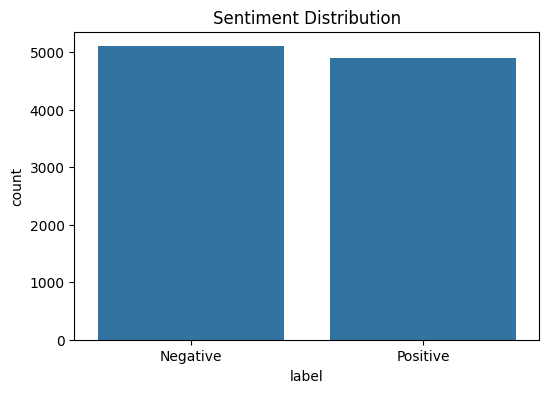

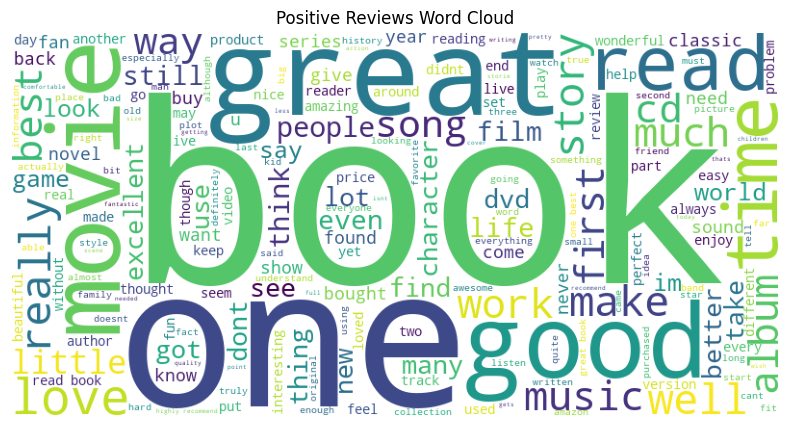

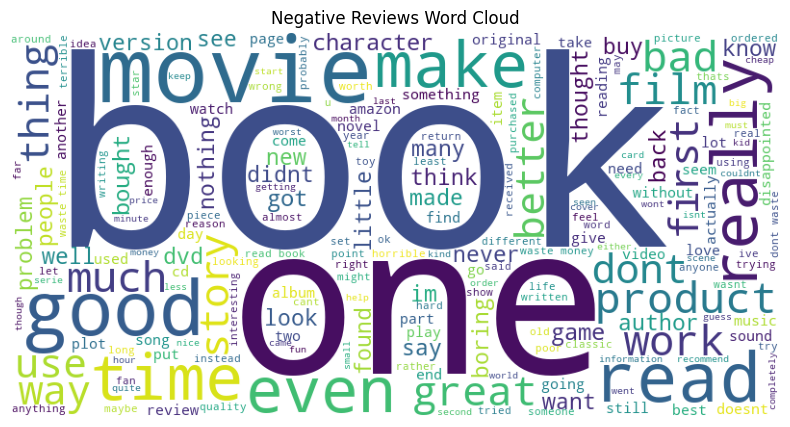


TF-IDF Shape: (10000, 10000)

Accuracy:
85.65 %

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1019
           1       0.85      0.86      0.85       981

    accuracy                           0.86      2000
   macro avg       0.86      0.86      0.86      2000
weighted avg       0.86      0.86      0.86      2000



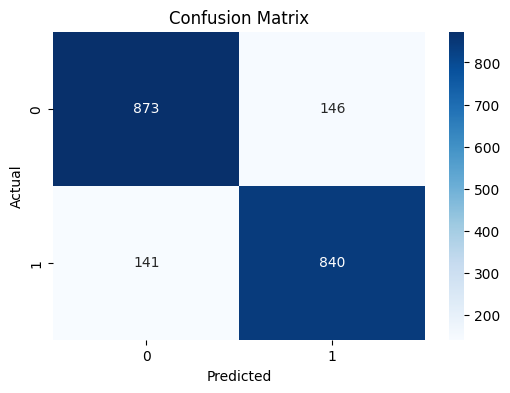


Cross Validation Accuracy:
[0.8665 0.835  0.834  0.843  0.859 ]

Mean CV Accuracy:
84.75 %

Prediction: Positive Review


In [6]:
# ==========================================
# AMAZON REVIEW SENTIMENT ANALYSIS PROJECT
# ==========================================

# Import Libraries
import pandas as pd
import numpy as np
import re
import string

import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

# Download Stopwords
nltk.download('stopwords')

# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv("amazonreviews (1).tsv", sep='\t')

print("Dataset Shape:", df.shape)

print("\nFirst 5 Rows:")
print(df.head())

# ==========================================
# DATA CLEANING
# ==========================================

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Remove missing reviews
df.dropna(inplace=True)

# Remove duplicate reviews
df.drop_duplicates(inplace=True)

print("\nDataset Shape After Cleaning:")
print(df.shape)

# ==========================================
# LABEL ENCODING
# ==========================================

df['label'] = df['label'].map({
    'pos':1,
    'neg':0
})

# ==========================================
# TEXT PREPROCESSING
# ==========================================

stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+', '', text)

    # Remove Numbers
    text = re.sub(r'\d+', '', text)

    # Remove Punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenization
    words = text.split()

    # Remove Stopwords
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df['clean_review'] = df['review'].apply(clean_text)

print("\nCleaned Text Example:")
print(df['clean_review'].iloc[0])

# ==========================================
# EXPLORATORY DATA ANALYSIS
# ==========================================

# Sentiment Distribution

plt.figure(figsize=(6,4))

sns.countplot(x=df['label'])

plt.title("Sentiment Distribution")
plt.xticks([0,1],['Negative','Positive'])
plt.show()

# ==========================================
# WORD CLOUDS
# ==========================================

positive_reviews = " ".join(
    df[df['label']==1]['clean_review']
)

negative_reviews = " ".join(
    df[df['label']==0]['clean_review']
)

# Positive Word Cloud

wordcloud_pos = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_pos)
plt.axis('off')
plt.title("Positive Reviews Word Cloud")
plt.show()

# Negative Word Cloud

wordcloud_neg = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(negative_reviews)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud_neg)
plt.axis('off')
plt.title("Negative Reviews Word Cloud")
plt.show()

# ==========================================
# TF-IDF FEATURE EXTRACTION
# ==========================================

vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1,2)
)

X = vectorizer.fit_transform(
    df['clean_review']
)

y = df['label']

print("\nTF-IDF Shape:", X.shape)

# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================
# MODEL BUILDING
# LOGISTIC REGRESSION
# ==========================================

model = LogisticRegression(
    max_iter=2000,
    C=2
)

model.fit(X_train, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

y_pred = model.predict(X_test)

# ==========================================
# EVALUATION
# ==========================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

print("\nAccuracy:")
print(round(accuracy*100,2), "%")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred
    )
)

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# ==========================================
# CROSS VALIDATION
# ==========================================

cv_scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("\nCross Validation Accuracy:")
print(cv_scores)

print("\nMean CV Accuracy:")
print(round(cv_scores.mean()*100,2), "%")

# ==========================================
# TEST CUSTOM REVIEW
# ==========================================

sample_review = [
    "This product is amazing and works perfectly"
]

sample_review = [
    clean_text(text)
    for text in sample_review
]

sample_vector = vectorizer.transform(
    sample_review
)

prediction = model.predict(
    sample_vector
)

if prediction[0] == 1:
    print("\nPrediction: Positive Review")
else:
    print("\nPrediction: Negative Review")